<a href="https://colab.research.google.com/github/Ram630/Household-Energy-Consumption-Forecasting/blob/main/notebooks/energy_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Household Energy Consumption Forecasting Pipeline
This section handles end-to-end data processing, feature engineering, model training, and artifact saving for predicting daily energy demand.

### Workflow Steps:
1. **Data Preprocessing:** Aggregates hourly appliance consumption logs into daily household totals.
2. **Feature Engineering:** Generates autoregressive lag features (`kwh_lag_1`, `kwh_lag_7`), 7-day rolling means, and calendar/one-hot categorical features.
3. **Model Training:** Trains a Random Forest Regressor to predict daily electricity usage (`total_kwh`).
4. **Export:** Saves the trained model artifact as a `.pkl` file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load raw hourly appliance consumption dataset
raw_df = pd.read_csv('appliance_usage_dataset.csv')

# Ensure timestamp is formatted properly
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])

# Compute total hourly consumption across all appliances
appliance_cols = ['ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
raw_df['total_kwh'] = raw_df[appliance_cols].sum(axis=1)

# Handle categorical missing values (normal non-holiday days)
raw_df['festival'] = raw_df['festival'].fillna('None')
raw_df['season'] = raw_df['season'].fillna('Unknown')

# Aggregate hourly data into daily household totals
daily_df = raw_df.groupby(['house_id', pd.Grouper(key='timestamp', freq='D')]).agg({
    'ac': 'sum',
    'fridge': 'sum',
    'lights': 'sum',
    'fans': 'sum',
    'washing_machine': 'sum',
    'tv': 'sum',
    'total_kwh': 'sum',
    'season': 'first',
    'festival': 'first'
}).reset_index()

# Sort chronologically per household
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
# Autoregressive Lag Features
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# Temporal/Calendar Features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# Categorical One-Hot Encoding
encoded_df = pd.get_dummies(daily_df, columns=['house_id', 'season', 'festival'], drop_first=True)

# Clean rows affected by initial lag shifts
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = encoded_df.dropna(subset=lag_cols).reset_index(drop=True)

# ==========================================
# 3. MODEL TRAINING & EVALUATION
# ==========================================
ignore_cols = ['timestamp', 'total_kwh', 'ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
features = [col for col in clean_df.columns if col not in ignore_cols]
target = 'total_kwh'

X = clean_df[features]
y = clean_df[target]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Model Evaluation Metrics
predictions = model.predict(X_test)
print("--- MODEL PERFORMANCE METRICS ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE:      {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE:     {root_mean_squared_error(y_test, predictions):.3f} kWh")

# ==========================================
# 4. SAVE MODEL ARTIFACT
# ==========================================
joblib.dump(model, 'random_forest_energy_model.pkl')
print("\nModel artifact successfully saved to 'random_forest_energy_model.pkl'")

--- MODEL PERFORMANCE METRICS ---
R² Score: 0.984
MAE:      1.035 kWh
RMSE:     1.298 kWh

Model artifact successfully saved to 'random_forest_energy_model.pkl'


# 30-Day Future Energy Consumption Forecast
This section uses the trained model to perform recursive day-by-day forecasting for the next full month immediately following the end of the dataset.

### Outputs:
* **Forecast Range:** 30 consecutive calendar days.
* **Visualization:** Date-wise daily energy consumption trend chart with daily average reference line.
* **Monthly Summary:** Total predicted energy usage in Kilowatt-Hours (kWh).

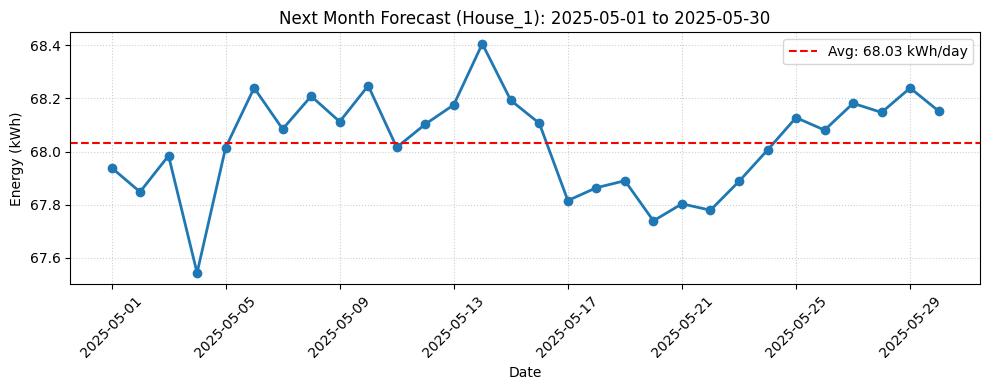

Dataset End Date:                    2025-04-30
Forecast Period:                     2025-05-01 to 2025-05-30
Total Predicted Usage (Next Month): 2040.93 kWh


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Dynamically pick the target house column available in clean_df
house_cols = [col for col in features if col.startswith('house_id_')]
target_house_col = house_cols[0] if house_cols else None

# Filter data for selected household using original daily_df
target_house_id = daily_df['house_id'].unique()[0]
house_df = clean_df[daily_df.loc[clean_df.index, 'house_id'] == target_house_id].sort_values('timestamp').copy()

# 2. Get last date in dataset & history
last_date = clean_df['timestamp'].max()
history = list(house_df['total_kwh'].values)
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# 3. Forecast loop
future_preds = []
for future_date in future_dates:
    input_data = {
        'day_of_week': future_date.dayofweek,
        'day_of_month': future_date.day,
        'month': future_date.month,
        'kwh_lag_1': history[-1],
        'kwh_lag_7': history[-7],
        'kwh_roll_mean_7': np.mean(history[-7:])
    }
    for col in features:
        if col not in input_data:
            input_data[col] = 1 if col == target_house_col else 0

    pred_kwh = model.predict(pd.DataFrame([input_data])[features])[0]
    future_preds.append(pred_kwh)
    history.append(pred_kwh)

forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_kWh': future_preds})

# 4. Visualization
plt.figure(figsize=(10, 4))
plt.plot(forecast_df['Date'], forecast_df['Predicted_kWh'], marker='o', color='#1f77b4', linewidth=2)
plt.axhline(forecast_df['Predicted_kWh'].mean(), color='red', linestyle='--', label=f"Avg: {forecast_df['Predicted_kWh'].mean():.2f} kWh/day")
plt.title(f"Next Month Forecast ({target_house_id}): {future_dates[0].strftime('%Y-%m-%d')} to {future_dates[-1].strftime('%Y-%m-%d')}")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Output summary
print(f"Dataset End Date:                    {last_date.strftime('%Y-%m-%d')}")
print(f"Forecast Period:                     {future_dates[0].strftime('%Y-%m-%d')} to {future_dates[-1].strftime('%Y-%m-%d')}")
print(f"Total Predicted Usage (Next Month): {forecast_df['Predicted_kWh'].sum():.2f} kWh")